# Esercizio 01 — Generatore pseudo-casuale e metodi Monte Carlo

In questo notebook vengono analizzati i risultati dell'esercizio 01. Gli esercizi sono divisi in tre parti:

1. test del generatore pseudo-casuale uniforme tramite media, varianza e test del $\chi^2$;
2. verifica del Teorema del Limite Centrale per variabili uniformi discrete, esponenziali e Cauchy-Lorentz;
3. simulazione dell'esperimento di Buffon per stimare $\pi$.

I file numerici letti dal notebook sono stati generati dai codici C++ nella cartella `Ex_01/` e salvati nella cartella `results/`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2, norm, cauchy

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True

## Metodo a blocchi per la stima dell'incertezza

In una simulazione Monte Carlo non basta calcolare una media: bisogna anche stimare quanto quella media sia affidabile. Per questo si usa il **data blocking**.

L'idea è dividere i dati in $N$ blocchi. In ogni blocco si calcola una stima indipendente della quantità osservabile, che indichiamo con $A_i$. Dopo $n$ blocchi si calcolano la media progressiva

$$
\langle A \rangle_n = \frac{1}{n}\sum_{i=1}^{n} A_i
$$

e la media progressiva dei quadrati

$$
\langle A^2 \rangle_n = \frac{1}{n}\sum_{i=1}^{n} A_i^2.
$$

L'incertezza statistica sulla media progressiva è stimata come

$$
\sigma_{\langle A \rangle}(n) =
\sqrt{\frac{\langle A^2 \rangle_n - \langle A \rangle_n^2}{n-1}}.
$$

Nel codice C++ l'indice dei blocchi parte da zero, quindi al primo blocco l'errore viene posto uguale a zero. Questo è naturale: con un solo blocco non si può ancora stimare la dispersione tra blocchi.

Il metodo funziona perché le stime di blocco vengono trattate come misure statisticamente indipendenti della stessa quantità. Questo ci permetterà di utilizzare il Teorema del Limite Centrale. Aumentando il numero di blocchi, la media progressiva deve stabilizzarsi attorno al valore atteso. L'incertezza sulla media, non la dispersione dei singoli dati, diminuisce circa come $1/\sqrt{N}$.

## Esercizio 01.1 — Test del generatore uniforme

Il generatore pseudo-casuale viene testato producendo numeri uniformi in $[0,1)$. Per una variabile uniforme continua $r$, i valori teorici sono

$$
\langle r \rangle = \frac{1}{2},
\qquad
\sigma^2 = \frac{1}{12}.
$$

Nel primo grafico mostriamo la media progressiva a blocchi sottratta dal valore teorico, cioè

$$
\langle r \rangle - \frac{1}{2}.
$$

Se il generatore è corretto, i punti devono essere compatibili con zero.

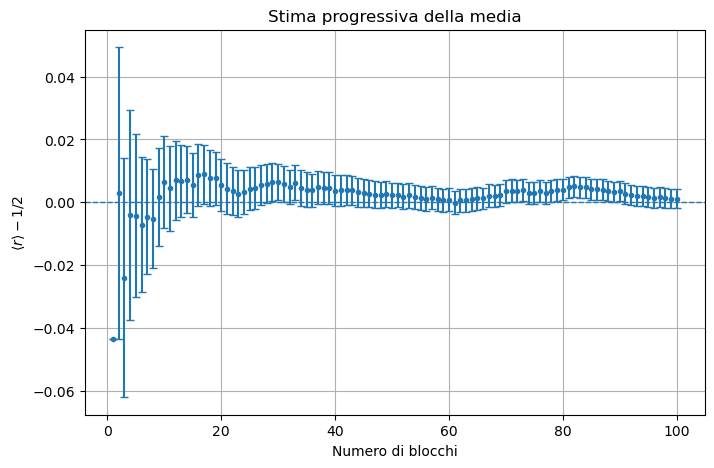

In [2]:
mean_var_data = np.loadtxt("results/mean_variance_results.txt")

blocks = mean_var_data[:, 0]
throws = mean_var_data[:, 1]
mean_minus_expected = mean_var_data[:, 2]
mean_error = mean_var_data[:, 3]
variance_minus_expected = mean_var_data[:, 4]
variance_error = mean_var_data[:, 5]

plt.figure()
plt.errorbar(blocks, mean_minus_expected, yerr=mean_error, fmt="o", markersize=3, capsize=3)
plt.axhline(0.0, linestyle="--", linewidth=1)
plt.xlabel("Numero di blocchi")
plt.ylabel(r"$\langle r \rangle - 1/2$")
plt.title("Stima progressiva della media")
plt.show()

Le barre d'errore del grafico precedente rappresentano l'errore statistico sulla media stimata, non la dispersione dei singoli numeri casuali. Nel blocking method ci aspettiamo che questa incertezza diminuisca approssimativamente come $1/\sqrt{N_{{blocchi}}}$.

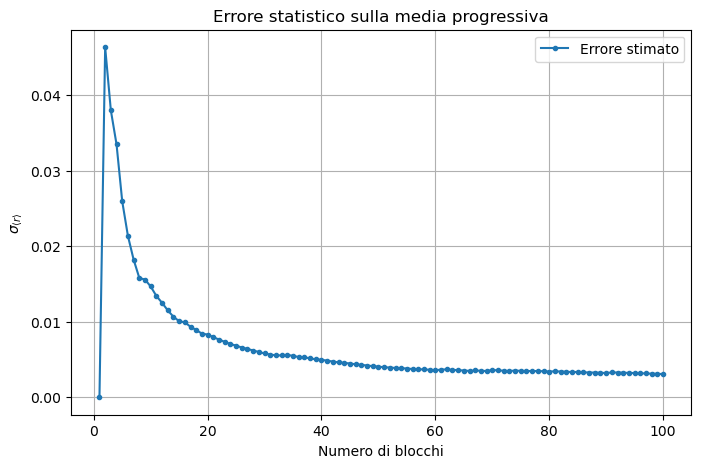

In [3]:
plt.figure()
plt.plot(blocks, mean_error, marker="o", markersize=3, label="Errore stimato")
plt.xlabel("Numero di blocchi")
plt.ylabel(r"$\sigma_{\langle r \rangle}$")
plt.title("Errore statistico sulla media progressiva")
plt.legend()
plt.show()

Il secondo test riguarda la varianza della distribuzione uniforme: in ogni blocco la varianza viene stimata rispetto alla media del blocco,

$$
s_i^2 = \frac{1}{L-1}\sum_{j=1}^{L}(r_j-\bar r_i)^2,
$$

con $L$ numero di lanci nel blocco. Successivamente si applica il metodo a blocchi ai valori $s_i^2$. Il confronto teorico resta $1/12$, cioè la varianza della distribuzione uniforme in $[0,1)$.

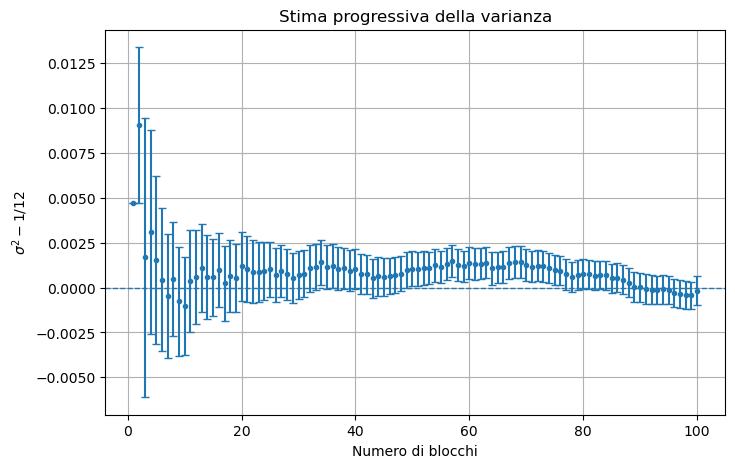

In [4]:
plt.figure()
plt.errorbar(blocks, variance_minus_expected, yerr=variance_error, fmt="o", markersize=3, capsize=3)
plt.axhline(0.0, linestyle="--", linewidth=1)
plt.xlabel("Numero di blocchi")
plt.ylabel(r"$\sigma^2 - 1/12$")
plt.title("Stima progressiva della varianza")
plt.show()

Anche la varianza viene stimata blocco per blocco. L'errore mostrato qui è quindi l'incertezza statistica sulla stima progressiva della varianza, che tende a ridursi quando aumenta il numero di blocchi.

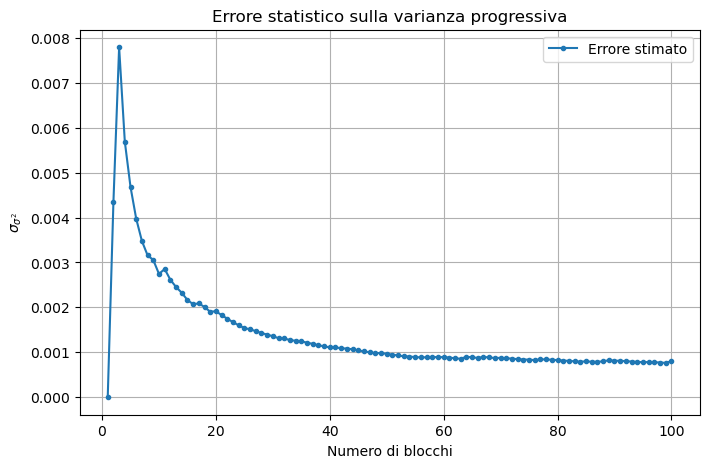

In [5]:
plt.figure()
plt.plot(blocks, variance_error, marker="o", markersize=3, label="Errore stimato")
plt.xlabel("Numero di blocchi")
plt.ylabel(r"$\sigma_{\sigma^2}$")
plt.title("Errore statistico sulla varianza progressiva")
plt.legend()
plt.show()

### Test del $\chi^2$

Per controllare in modo più diretto l'uniformità del generatore, l'intervallo $[0,1]$ è stato diviso in 100 sottointervalli uguali. Per ogni test vengono generati $10^4$ numeri pseudo-casuali. Se il generatore è uniforme, il numero atteso di eventi in ogni bin è

$$
E = \frac{10^4}{100}=100.
$$

La statistica usata è

$$
\chi^2 = \sum_{i=1}^{100}\frac{(O_i-E)^2}{E},
$$

dove $O_i$ è il numero osservato nel bin $i$. Ripetendo il test 100 volte, ci si aspetta di ottenere valori dell'ordine di 100. Più precisamente, poiché i conteggi sono vincolati dal numero totale di estrazioni, i gradi di libertà sono $100-1=99$.

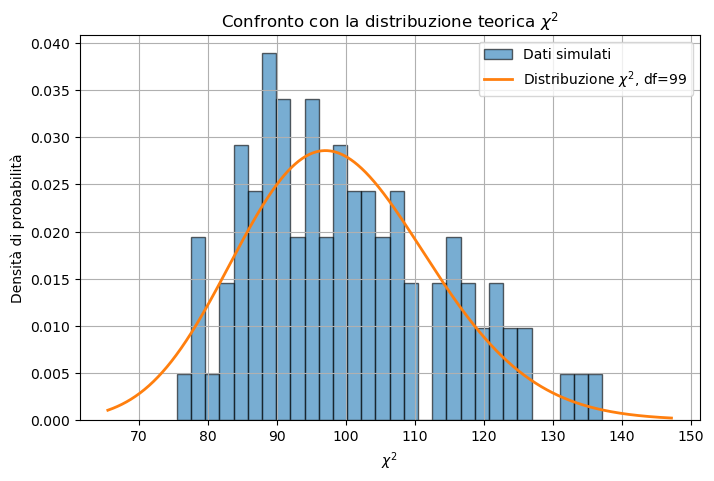

In [6]:
chi2_data = np.loadtxt("results/chi2_results.txt")
chi2_values = chi2_data[:, 1]

plt.figure()
plt.hist(chi2_values, bins=30, density=True, alpha=0.6, edgecolor="black", label="Dati simulati")

x = np.linspace(max(0, chi2_values.min() - 10), chi2_values.max() + 10, 1000)
plt.plot(x, chi2.pdf(x, df=99), linewidth=2, label=r"Distribuzione $\chi^2$, df=99")

plt.xlabel(r"$\chi^2$")
plt.ylabel("Densità di probabilità")
plt.title(r"Confronto con la distribuzione teorica $\chi^2$")
plt.legend()
plt.show()

## Esercizio 01.2 — Teorema del Limite Centrale

In questa parte sono state generate tre famiglie di variabili casuali:

1. dado standard, cioè una variabile discreta uniforme sui valori $1,2,3,4,5,6$;
2. variabile esponenziale con $\lambda=1$;
3. variabile di Cauchy-Lorentz con $\mu=0$ e $\Gamma=1$.

Per ogni distribuzione si studia

$$
S_N = \frac{1}{N}\sum_{i=1}^{N}x_i,
$$

per $N=1,2,10,100$, usando $10^4$ realizzazioni.

Per la distribuzione esponenziale e per quella di Cauchy-Lorentz si è usato il metodo dell'inversione della cumulativa. Se $u$ è uniforme in $[0,1)$, allora per l'esponenziale si può usare

$$
x = -\frac{1}{\lambda}\ln(1-u),
$$

mentre per la Cauchy-Lorentz

$$
x = \mu + \Gamma \tan\left[\pi\left(u-\frac{1}{2}\right)\right].
$$

Il Teorema del Limite Centrale afferma che la somma, o la media, di molte variabili indipendenti e identicamente distribuite tende a una gaussiana dopo opportuna normalizzazione, purché la distribuzione di partenza abbia media e varianza finite. Per questo ci aspettiamo una forma gaussiana per il dado e per l'esponenziale quando $N$ diventa grande. Il caso Cauchy è diverso: la distribuzione non ha varianza finita, quindi il Teorema del Limite Centrale standard non si applica.

In [7]:
dice_data = np.loadtxt("results/standard_dice_results.txt")
exp_data = np.loadtxt("results/exponential_results.txt")
cauchy_data = np.loadtxt("results/cauchy_results.txt")

N_values = [1, 2, 10, 100]

### Dado standard

Per il dado standard la media teorica di un lancio è

$$
\mu = \frac{1+2+3+4+5+6}{6}=3.5,
$$

mentre la varianza è

$$
\sigma^2 = \frac{35}{12}.
$$

Per la media di $N$ lanci, la varianza si riduce come $\sigma^2/N$. Per $N=100$, quindi, ci aspettiamo una gaussiana centrata in 3.5 con deviazione standard

$$
\frac{\sigma}{\sqrt{100}}.
$$

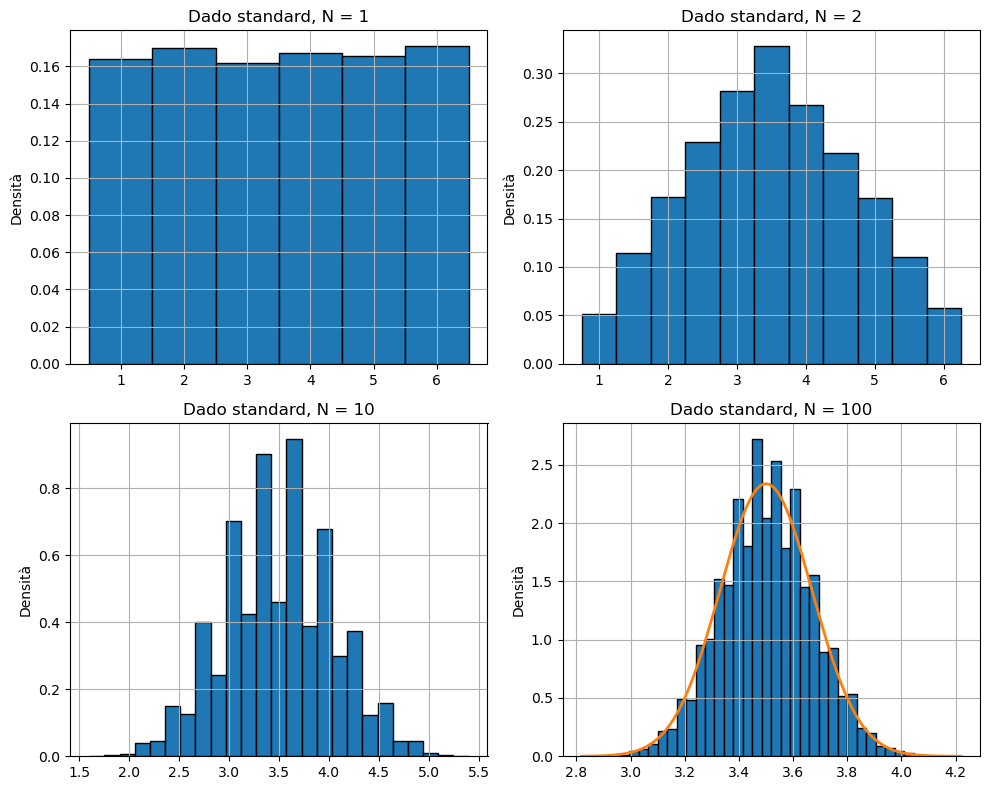

In [8]:
dice_bins = [
    np.arange(0.5, 7.5, 1.0),
    np.arange(0.75, 6.75, 0.5),
    25,
    40,
]

mu_dice = 3.5
sigma_dice_N100 = np.sqrt((35.0 / 12.0) / 100.0)

fig, axes = plt.subplots(2, 2, figsize=(10, 8))

for i, ax in enumerate(axes.flat):
    values = dice_data[:, i]
    ax.hist(values, bins=dice_bins[i], density=True, edgecolor="black")
    ax.set_title(f"Dado standard, N = {N_values[i]}")
    ax.set_ylabel("Densità")

    if N_values[i] == 100:
        x = np.linspace(values.min(), values.max(), 1000)
        ax.plot(x, norm.pdf(x, loc=mu_dice, scale=sigma_dice_N100), linewidth=2)

plt.tight_layout()
plt.show()

Per $N=1$ si riconosce la distribuzione discreta del dado. Aumentando $N$, la distribuzione di $S_N$ si concentra attorno al valore medio 3.5 e diventa progressivamente più simile a una gaussiana. Questo è esattamente il comportamento previsto dal Teorema del Limite Centrale.

### Distribuzione esponenziale

Per una variabile esponenziale con $\lambda=1$, media e varianza valgono entrambe 1:

$$
\mu = 1,
\qquad
\sigma^2 = 1.
$$

Anche in questo caso, la media di $N$ variabili indipendenti deve tendere a una distribuzione gaussiana centrata in 1, con deviazione standard $1/\sqrt{N}$. Per $N=100$, la deviazione standard attesa è quindi 0.1.

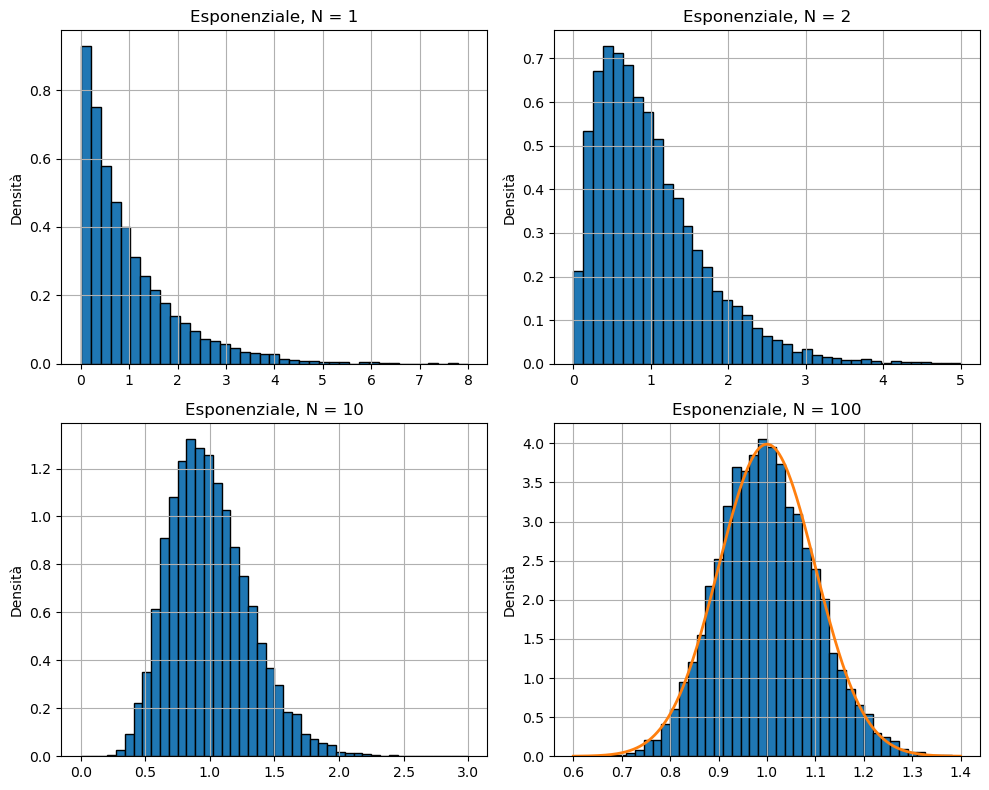

In [9]:
exp_bins = [
    np.linspace(0, 8, 40),
    np.linspace(0, 5, 40),
    np.linspace(0, 3, 45),
    np.linspace(0.6, 1.4, 45),
]

mu_exp = 1.0
sigma_exp_N100 = np.sqrt(1.0 / 100.0)

fig, axes = plt.subplots(2, 2, figsize=(10, 8))

for i, ax in enumerate(axes.flat):
    values = exp_data[:, i]
    ax.hist(values, bins=exp_bins[i], density=True, edgecolor="black")
    ax.set_title(f"Esponenziale, N = {N_values[i]}")
    ax.set_ylabel("Densità")

    if N_values[i] == 100:
        x = np.linspace(exp_bins[i][0], exp_bins[i][-1], 1000)
        ax.plot(x, norm.pdf(x, loc=mu_exp, scale=sigma_exp_N100), linewidth=2)

plt.tight_layout()
plt.show()

Per $N=1$ la distribuzione è chiaramente asimmetrica, come previsto per una esponenziale. Per $N=100$, invece, l'istogramma della media campionaria è praticamente simmetrico e ben descritto da una gaussiana. La distribuzione di partenza non è gaussiana, ma ha media e varianza finite: questo è il punto essenziale che permette al Teorema del Limite Centrale di funzionare.

### Distribuzione di Cauchy-Lorentz

La distribuzione di Cauchy-Lorentz rappresenta il controesempio importante di questo esercizio. Pur essendo una distribuzione perfettamente normalizzata, non ha media e varianza finite. Di conseguenza, la media campionaria non converge verso una gaussiana.

Nel caso standard $\mu=0$, $\Gamma=1$, la Cauchy è inoltre una distribuzione stabile: la media di $N$ variabili Cauchy indipendenti ha ancora distribuzione Cauchy con gli stessi parametri. Per questo gli istogrammi non si restringono come nel caso del dado o dell'esponenziale.

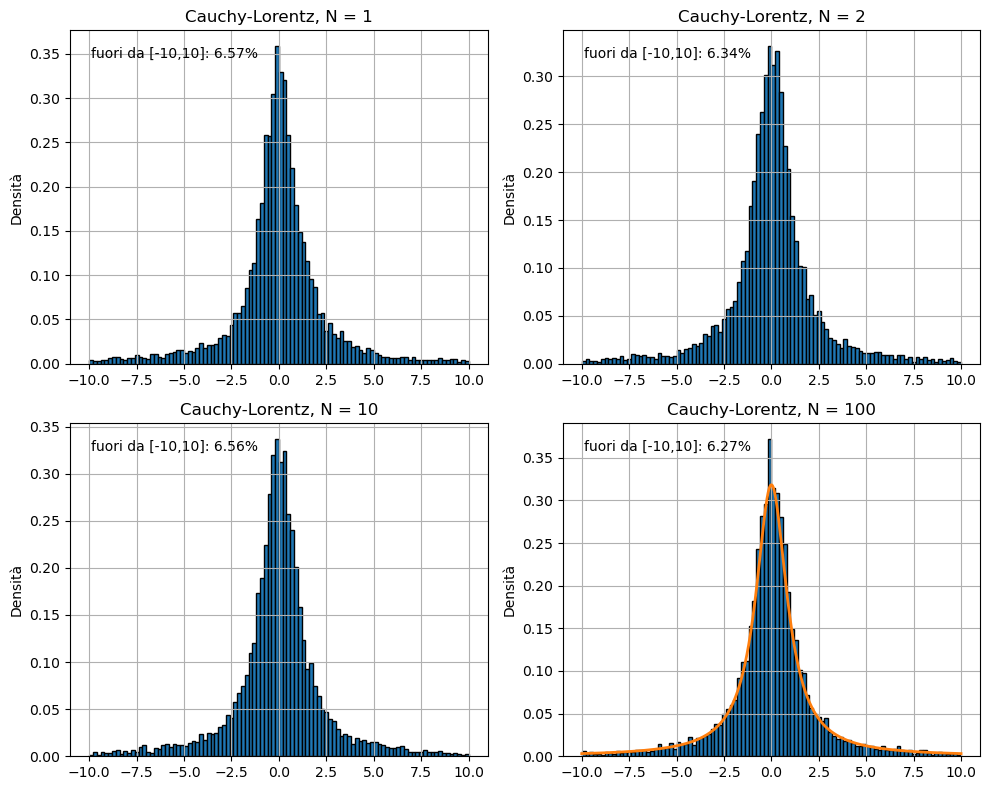

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

for i, ax in enumerate(axes.flat):
    values = cauchy_data[:, i]

    inside = (values >= -10) & (values <= 10)
    outside_percentage = 100.0 * np.sum(~inside) / len(values)

    ax.hist(values, bins=100, range=(-10, 10), density=True, edgecolor="black")
    ax.set_title(f"Cauchy-Lorentz, N = {N_values[i]}")
    ax.set_ylabel("Densità")

    ax.text(
        0.05, 0.95,
        f"fuori da [-10,10]: {outside_percentage:.2f}%",
        transform=ax.transAxes,
        va="top"
    )

    if N_values[i] == 100:
        x = np.linspace(-10, 10, 1000)
        ax.plot(x, cauchy.pdf(x, loc=0, scale=1), linewidth=2)

plt.tight_layout()
plt.show()

Il confronto mostra che, a differenza dei casi precedenti, aumentando $N$ la distribuzione non collassa attorno a un valore medio e non assume forma gaussiana. La presenza di code molto pesanti rende frequenti eventi estremi, che continuano a influenzare la media campionaria anche per valori grandi di $N$.

## Esercizio 01.3 — Esperimento di Buffon

Nell'esperimento di Buffon si lancia un ago di lunghezza $L$ su un piano con linee parallele distanti $d$, con $d>L$. La probabilità che l'ago intersechi una linea è

$$
P = \frac{2L}{\pi d}.
$$

Se $N_{thr}$ è il numero totale di lanci e $N_{hit}$ il numero di intersezioni osservate, allora

$$
P \simeq \frac{N_{hit}}{N_{thr}},
$$

da cui si ottiene la stima

$$
\pi \simeq \frac{2L N_{thr}}{d N_{hit}}.
$$

Nel codice sono stati scelti $L=1$ e $d=2$. L'orientazione dell'ago è stata generata senza estrarre direttamente un angolo uniforme in $[0,\pi]$, perché questo avrebbe richiesto di usare $\pi$ proprio nell'esperimento che vuole stimarlo. Invece si genera un punto casuale nel cerchio unitario e si ricava

$$
|\sin\theta| = \frac{|y|}{\sqrt{x^2+y^2}}.
$$

L'ago interseca una linea se la distanza del suo centro dalla linea più vicina è minore della proiezione verticale della mezza lunghezza dell'ago.

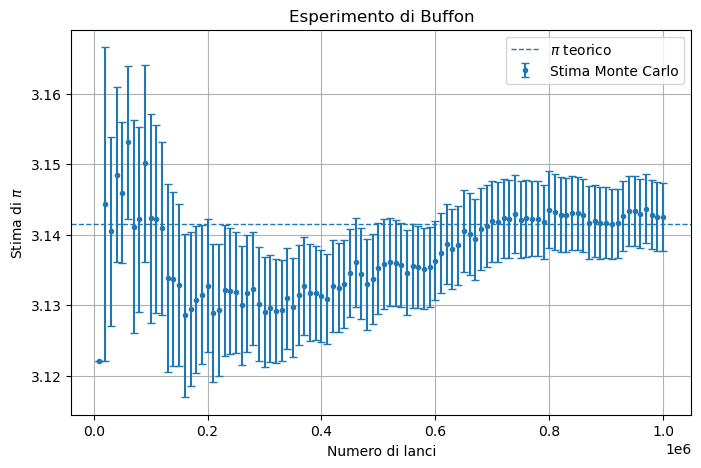

Stima finale di pi: 3.142470 ± 0.004819
Valore teorico di pi: 3.141593


In [11]:
buffon_data = np.loadtxt("results/buffon.txt")

throws_buffon = buffon_data[:, 0]
pi_estimate = buffon_data[:, 1]
pi_error = buffon_data[:, 2]

plt.figure()
plt.errorbar(throws_buffon, pi_estimate, yerr=pi_error, fmt="o", markersize=3, capsize=3, label="Stima Monte Carlo")
plt.axhline(np.pi, linestyle="--", linewidth=1, label=r"$\pi$ teorico")
plt.xlabel("Numero di lanci")
plt.ylabel(r"Stima di $\pi$")
plt.title("Esperimento di Buffon")
plt.legend()
plt.show()

print(f"Stima finale di pi: {pi_estimate[-1]:.6f} ± {pi_error[-1]:.6f}")
print(f"Valore teorico di pi: {np.pi:.6f}")

La stima di $\pi$ è ottenuta come media progressiva delle stime di blocco. Aumentando il numero totale di lanci, l'incertezza statistica diminuisce come previsto per una simulazione Monte Carlo.

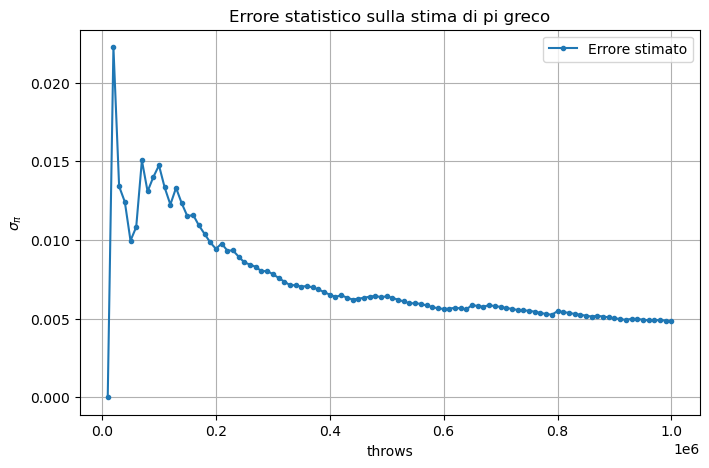

In [12]:
valid = pi_error > 0
reference_pi_error = pi_error[valid][0] * np.sqrt(throws_buffon[valid][0] / throws_buffon[valid])

plt.figure()
plt.plot(throws_buffon, pi_error, marker="o", markersize=3, label="Errore stimato")
plt.ylabel(r"$\sigma_{\pi}$")
plt.xlabel("throws")
plt.title(r"Errore statistico sulla stima di pi greco")
plt.legend()
plt.show()

## Conclusioni

L'esercizio mostra tre idee centrali del metodo Monte Carlo e del data blocking.

La prima è che ogni stima numerica deve essere accompagnata da un'incertezza statistica. Il blocking method permette di ottenere questa incertezza in modo semplice e robusto, trattando le stime di blocco come misure indipendenti.

La seconda è che un generatore pseudo-casuale può essere controllato confrontando osservabili note, come media e varianza della distribuzione uniforme, e usando test statistici come il $\chi^2$. Nessun singolo test dimostra in modo assoluto che un generatore sia perfetto, ma la compatibilità dei risultati con le previsioni teoriche è un controllo necessario.

La terza è che il Teorema del Limite Centrale ha ipotesi precise. Funziona per distribuzioni con media e varianza finite, come il dado e l'esponenziale, ma non per distribuzioni a code pesanti come la Cauchy-Lorentz. Questo spiega perché nel caso Cauchy la media campionaria non diventa gaussiana nemmeno per $N=100$.